# Prepare the Data

## Dataset and RNN Justification

We use the **Human Activity Recognition (HAR) dataset**, which contains time-series data collected from smartphone sensors (accelerometers and gyroscopes) while subjects perform daily activities.

Each sample is a sequence of **128 time steps** across **9 input features**, corresponding to motion signals.

This is a **many-to-one classification** task: each time window is associated with one activity label (e.g., walking, sitting, etc.).

RNN-based models like **LSTM** and **GRU** are well-suited for this problem because they can model **temporal dependencies**, making them effective for capturing sequential patterns in time-series sensor data.

In [1]:
import os
import pandas as pd
import numpy as np

# Set this to your actual extracted folder path
base_path = r"C:\Users\sdam1\Desktop\IESEG 1st Year\Fundamentals of Deep Learning\Group Project\UCI HAR Dataset"

def load_data(base_path, split='train'):
    X_path = os.path.join(base_path, split, f"X_{split}.txt")
    y_path = os.path.join(base_path, split, f"y_{split}.txt")
    subject_path = os.path.join(base_path, split, f"subject_{split}.txt")

    X = pd.read_csv(X_path, sep='\s+', header=None).values
    y = pd.read_csv(y_path, header=None).values.ravel()
    subject = pd.read_csv(subject_path, header=None).values.ravel()

    return X, y, subject

# Load training and test data
X_train, y_train, subj_train = load_data(base_path, 'train')
X_test, y_test, subj_test = load_data(base_path, 'test')

# Print shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\sdam1\AppData\Local\Temp\ipykernel_18576\2352330755.py:13: SyntaxWarning: invalid escape sequence '\s'
  X = pd.read_csv(X_path, sep='\s+', header=None).values


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape: (2947, 561)
y_test shape: (2947,)


In [2]:
def load_inertial_signals(base_path, split='train'):
    signal_types = [
        'body_acc_x', 'body_acc_y', 'body_acc_z',
        'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
        'total_acc_x', 'total_acc_y', 'total_acc_z'
    ]
    
    signal_data = []
    for signal in signal_types:
        file_path = os.path.join(base_path, split, 'Inertial Signals', f"{signal}_{split}.txt")
        data = pd.read_csv(file_path, delim_whitespace=True, header=None).values
        signal_data.append(data)

    # Stack to get shape: (samples, timesteps, features)
    return np.transpose(np.array(signal_data), (1, 2, 0))  # reshape to (7352, 128, 9)

# Load raw input signals
X_train_seq = load_inertial_signals(base_path, 'train')
X_test_seq = load_inertial_signals(base_path, 'test')

# Confirm shape
print("X_train_seq shape:", X_train_seq.shape)  # should be (7352, 128, 9)
print("X_test_seq shape:", X_test_seq.shape)    # should be (2947, 128, 9)

C:\Users\sdam1\AppData\Local\Temp\ipykernel_18576\1934003894.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None).values
C:\Users\sdam1\AppData\Local\Temp\ipykernel_18576\1934003894.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None).values
C:\Users\sdam1\AppData\Local\Temp\ipykernel_18576\1934003894.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(file_path, delim_whitespace=True, header=None).values
C:\Users\sdam1\AppData\Local\Temp\ipykernel_18576\1934003894.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated an

X_train_seq shape: (7352, 128, 9)
X_test_seq shape: (2947, 128, 9)


In [3]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train - 1)
y_test_cat = to_categorical(y_test - 1)

# Build & Train LSTM Models

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_lstm_model(input_shape, units=64, layers=1):
    model = Sequential()
    for i in range(layers - 1):
        model.add(LSTM(units, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(units))  # Final LSTM layer
    model.add(Dropout(0.5))
    model.add(Dense(6, activation='softmax'))
    
    model.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
    return model

input_shape = (128, 9)
lstm_model = build_lstm_model(input_shape, units=64, layers=2)

history = lstm_model.fit(
    X_train_seq, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_test_seq, y_test_cat)
)

c:\ProgramData\anaconda3\envs\py\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 12s 87ms/step - accuracy: 0.4299 - loss: 1.3581 - val_accuracy: 0.6834 - val_loss: 0.7999
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - accuracy: 0.6949 - loss: 0.7231 - val_accuracy: 0.7296 - val_loss: 0.6761
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.8269 - loss: 0.4955 - val_accuracy: 0.8154 - val_loss: 0.5710
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.8349 - loss: 0.5392 - val_accuracy: 0.8585 - val_loss: 0.4069
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.9276 - loss: 0.2515 - val_accuracy: 0.8775 - val_loss: 0.3979
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.9332 - loss: 0.2021 - val_accuracy: 0.8310 - val_loss: 0.5676
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.9290 - loss: 0.2228 - val_accuracy: 0.8911 - val_loss: 0.3360
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.9404 - loss: 0.1635 - val_a

In [5]:
def build_simple_lstm_model(input_shape, units=32):
    model = Sequential()
    model.add(LSTM(units, input_shape=input_shape))  # Single LSTM layer
    model.add(Dropout(0.3))  # Lower dropout to retain more information
    model.add(Dense(6, activation='softmax'))  # Output layer for 6 classes

    model.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
    return model

# Build and train the simplified model
simple_lstm_model = build_simple_lstm_model(input_shape=(128, 9))

history_simple = simple_lstm_model.fit(
    X_train_seq, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_test_seq, y_test_cat)
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.3764 - loss: 1.5643 - val_accuracy: 0.5650 - val_loss: 1.0825
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6109 - loss: 0.9410 - val_accuracy: 0.6074 - val_loss: 1.0120
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6224 - loss: 0.9058 - val_accuracy: 0.6318 - val_loss: 0.8424
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6485 - loss: 0.7873 - val_accuracy: 0.6468 - val_loss: 0.7948
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6678 - loss: 0.7235 - val_accuracy: 0.6627 - val_loss: 0.7663
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.6893 - loss: 0.6746 - val_accuracy: 0.6685 - val_loss: 0.7754
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.6937 - loss: 0.6764 - val_accuracy: 0.6949 - val_loss: 0.7079
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.7288 - loss: 0.6270 - val_accu

In [6]:
def build_complex_lstm_model(input_shape, units=128, layers=3):
    model = Sequential()
    for i in range(layers - 1):
        model.add(LSTM(units, return_sequences=True, input_shape=input_shape))  # Intermediate layers
    model.add(LSTM(units))  # Final LSTM layer without return_sequences
    model.add(Dropout(0.6))  # Higher dropout to handle increased capacity
    model.add(Dense(6, activation='softmax'))  # Output layer for classification

    model.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
    return model

# Build and train the complex model
complex_lstm_model = build_complex_lstm_model(input_shape=(128, 9))

history_complex = complex_lstm_model.fit(
    X_train_seq, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_test_seq, y_test_cat)
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 39s 316ms/step - accuracy: 0.4902 - loss: 1.2236 - val_accuracy: 0.6709 - val_loss: 0.8022
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 368ms/step - accuracy: 0.7372 - loss: 0.6309 - val_accuracy: 0.7445 - val_loss: 0.5881
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 45s 391ms/step - accuracy: 0.7842 - loss: 0.5015 - val_accuracy: 0.7743 - val_loss: 0.6129
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 65s 570ms/step - accuracy: 0.8764 - loss: 0.3349 - val_accuracy: 0.8694 - val_loss: 0.3533
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 57s 496ms/step - accuracy: 0.9211 - loss: 0.2408 - val_accuracy: 0.9097 - val_loss: 0.2622
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 91s 788ms/step - accuracy: 0.9380 - loss: 0.1751 - val_accuracy: 0.9121 - val_loss: 0.2567
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 46s 401ms/step - accuracy: 0.9425 - loss: 0.1691 - val_accuracy: 0.8816 - val_loss: 0.4018
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 46s 397ms/step - accuracy: 0.9330 - loss: 0

# Build & Train GRU Models

In [7]:
from tensorflow.keras.layers import GRU

def build_gru_model(input_shape, units=64, layers=1):
    model = Sequential()
    for i in range(layers - 1):
        model.add(GRU(units, return_sequences=True, input_shape=input_shape))
    model.add(GRU(units))
    model.add(Dropout(0.5))
    model.add(Dense(6, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
    return model

gru_model = build_gru_model(input_shape, units=64, layers=2)

history_gru = gru_model.fit(
    X_train_seq, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_test_seq, y_test_cat)
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - accuracy: 0.3768 - loss: 1.4562 - val_accuracy: 0.4930 - val_loss: 1.1680
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 157ms/step - accuracy: 0.5825 - loss: 0.9649 - val_accuracy: 0.7116 - val_loss: 0.7126
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 188ms/step - accuracy: 0.8057 - loss: 0.4971 - val_accuracy: 0.8568 - val_loss: 0.4115
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 173ms/step - accuracy: 0.9293 - loss: 0.2113 - val_accuracy: 0.8616 - val_loss: 0.4348
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.9429 - loss: 0.1788 - val_accuracy: 0.8836 - val_loss: 0.3531
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 166ms/step - accuracy: 0.9400 - loss: 0.1730 - val_accuracy: 0.8714 - val_loss: 0.3729
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - accuracy: 0.9355 - loss: 0.1687 - val_accuracy: 0.8836 - val_loss: 0.3474
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 174ms/step - accuracy: 0.9447 - loss: 0

In [8]:
def build_simple_gru_model(input_shape, units=32):
    model = Sequential()
    model.add(GRU(units, input_shape=input_shape))  # Single GRU layer
    model.add(Dropout(0.3))  # Reduced dropout rate
    model.add(Dense(6, activation='softmax'))  # Output layer

    model.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
    return model

# Train the simplified GRU model
simple_gru_model = build_simple_gru_model(input_shape=(128, 9))

history_simple_gru = simple_gru_model.fit(
    X_train_seq, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_test_seq, y_test_cat)
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.3344 - loss: 1.6352 - val_accuracy: 0.4652 - val_loss: 1.3006
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4714 - loss: 1.2100 - val_accuracy: 0.5110 - val_loss: 1.1794
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5537 - loss: 1.0037 - val_accuracy: 0.5294 - val_loss: 1.0873
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - accuracy: 0.6423 - loss: 0.8154 - val_accuracy: 0.6332 - val_loss: 0.8656
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.6948 - loss: 0.6539 - val_accuracy: 0.6807 - val_loss: 0.7881
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.7314 - loss: 0.6101 - val_accuracy: 0.8005 - val_loss: 0.6479
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.8066 - loss: 0.4908 - val_accuracy: 0.8185 - val_loss: 0.5563
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8663 - loss: 0.3718 - val_accu

In [9]:
def build_complex_gru_model(input_shape, units=128, layers=3):
    model = Sequential()
    for i in range(layers - 1):
        model.add(GRU(units, return_sequences=True, input_shape=input_shape))  # Intermediate GRU layers
    model.add(GRU(units))  # Final GRU layer
    model.add(Dropout(0.6))  # Higher dropout for better generalization
    model.add(Dense(6, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])
    return model

# Train the complex GRU model
complex_gru_model = build_complex_gru_model(input_shape=(128, 9))

history_complex_gru = complex_gru_model.fit(
    X_train_seq, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_test_seq, y_test_cat)
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 85s 717ms/step - accuracy: 0.4556 - loss: 1.2917 - val_accuracy: 0.5443 - val_loss: 1.0402
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 49s 425ms/step - accuracy: 0.6994 - loss: 0.6947 - val_accuracy: 0.8588 - val_loss: 0.4256
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 50s 432ms/step - accuracy: 0.9393 - loss: 0.1783 - val_accuracy: 0.8683 - val_loss: 0.3750
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 49s 427ms/step - accuracy: 0.9333 - loss: 0.1609 - val_accuracy: 0.8945 - val_loss: 0.3612
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 53s 457ms/step - accuracy: 0.9390 - loss: 0.1520 - val_accuracy: 0.8945 - val_loss: 0.3195
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 49s 427ms/step - accuracy: 0.9497 - loss: 0.1279 - val_accuracy: 0.8999 - val_loss: 0.4153
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 49s 428ms/step - accuracy: 0.9457 - loss: 0.1415 - val_accuracy: 0.9077 - val_loss: 0.3183
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 49s 429ms/step - accuracy: 0.9432 - loss: 0

# Evaluate & Compare Performance

In [10]:
# Evaluate LSTM models
loss_lstm, acc_lstm = lstm_model.evaluate(X_test_seq, y_test_cat)
loss_simple_lstm, acc_simple_lstm = simple_lstm_model.evaluate(X_test_seq, y_test_cat)
loss_complex_lstm, acc_complex_lstm = complex_lstm_model.evaluate(X_test_seq, y_test_cat)

# Evaluate GRU models
loss_gru, acc_gru = gru_model.evaluate(X_test_seq, y_test_cat)
loss_simple_gru, acc_simple_gru = simple_gru_model.evaluate(X_test_seq, y_test_cat)
loss_complex_gru, acc_complex_gru = complex_gru_model.evaluate(X_test_seq, y_test_cat)

# Store results in a dictionary
results = {
    "Model": ["Baseline LSTM", "Simplified LSTM", "Complex LSTM", "Baseline GRU", "Simplified GRU", "Complex GRU"],
    "Accuracy": [acc_lstm, acc_simple_lstm, acc_complex_lstm, acc_gru, acc_simple_gru, acc_complex_gru],
    "Loss": [loss_lstm, loss_simple_lstm, loss_complex_lstm, loss_gru, loss_simple_gru, loss_complex_gru]
}

import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8613 - loss: 0.3383
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7551 - loss: 0.6169
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8820 - loss: 0.2997
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8418 - loss: 0.4743
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8423 - loss: 0.4714
93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8848 - loss: 0.4189
             Model  Accuracy      Loss
0    Baseline LSTM  0.907363  0.276342
1  Simplified LSTM  0.785884  0.560968
2     Complex LSTM  0.915168  0.244598
3     Baseline GRU  0.884628  0.411308
4   Simplified GRU  0.878860  0.417763
5      Complex GRU  0.909739  0.356681


## Model Performance Comparison

The following table summarizes the accuracy and loss of all six models:

| Model             | Accuracy | Loss    | Complexity       |
|------------------|---------|--------|------------------|
| **Baseline LSTM**     | 90.74%  | 0.2763 | Medium (2 layers) |
| **Simplified LSTM**   | 78.59%  | 0.5610 | Low (1 layer)     |
| **Complex LSTM**      | **91.52%**  | **0.2446** | High (3 layers)    |
| **Baseline GRU**      | 88.46%  | 0.4113 | Medium (2 layers) |
| **Simplified GRU**    | 87.89%  | 0.4178 | Low (1 layer)     |
| **Complex GRU**       | 90.97%  | 0.3567 | High (3 layers)    |

---

### Best Model: Complex LSTM
The **Complex LSTM model** achieved the **highest accuracy (91.52%)** and the **lowest loss (0.2446)**.  
The added complexity (3 layers, 128 units) enhanced performance, indicating that this model  
effectively captured **temporal dependencies** without overfitting.  

---

### Key Observations:

1. **LSTM vs GRU:**
   - In general, **LSTM models outperformed GRU models** in this task.  
   - The **Complex LSTM** was better than the **Complex GRU**, showing that LSTM's ability to capture  
     longer temporal dependencies suited this dataset.  

2. **Baseline vs Complex Models:**
   - Increasing the model complexity (more layers and units) consistently **improved accuracy** for both LSTM and GRU.  
   - The **complex models** (both LSTM and GRU) performed significantly better than their simplified counterparts.  
   - Complex models are more **expressive**, which helped in accurately capturing the **complex temporal patterns**  
     inherent in human activity recognition.  

3. **Baseline vs Simplified Models:**
   - Simplifying the models (reducing layers and units) led to a **significant drop in accuracy**,  
     especially for LSTM (from **90.74% to 78.59%**).  
   - This shows that a **single-layer model with fewer units** is **not sufficient** to learn the intricate patterns  
     in the data.  

4. **Training Stability:**
   - The **Complex LSTM** not only had the **highest accuracy** but also the **lowest loss**, indicating both  
     **effective training and stable generalization**.  
   - The **simplified models** had the **highest loss**, indicating potential **underfitting**.  

---

### Final Recommendation:
- Use the **Complex LSTM model** (3 layers, 128 units) as it achieved the **best accuracy and generalization**.  
- If **computational resources are limited**, the **Baseline LSTM** (90.74%) can be an alternative as it still performs well while being less complex.  
- Avoid using **simplified models** since they significantly **underperform** compared to the baseline and complex versions.

# Apply Attention

In [13]:
# Model Definition
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

# Define a Custom Attention Layer
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="attention_weight", 
                                 shape=(input_shape[-1], 1),
                                 initializer="random_normal",
                                 trainable=True)
        self.b = self.add_weight(name="attention_bias", 
                                 shape=(input_shape[1], 1),
                                 initializer="zeros",
                                 trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        score = K.dot(inputs, self.W) + self.b     # shape: (batch, timesteps, 1)
        score = K.squeeze(score, axis=-1)          # shape: (batch, timesteps)
        attention_weights = K.softmax(score, axis=1)  # shape: (batch, timesteps)
        attention_weights = K.expand_dims(attention_weights, axis=-1)  # (batch, timesteps, 1)
        context = inputs * attention_weights
        context = K.sum(context, axis=1)  # shape: (batch, features)
        return context

In [14]:
# Train the Complex LSTM with Attention model
lstm_attention_model = build_lstm_attention_model(input_shape=(128, 9))

history_lstm_attention = lstm_attention_model.fit(
    X_train_seq, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_test_seq, y_test_cat)
)


Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 339ms/step - accuracy: 0.4874 - loss: 1.2071 - val_accuracy: 0.7265 - val_loss: 0.7008
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 36s 315ms/step - accuracy: 0.7758 - loss: 0.5666 - val_accuracy: 0.8222 - val_loss: 0.4992
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 36s 314ms/step - accuracy: 0.9004 - loss: 0.2832 - val_accuracy: 0.9026 - val_loss: 0.2684
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 37s 320ms/step - accuracy: 0.9360 - loss: 0.1683 - val_accuracy: 0.9009 - val_loss: 0.2829
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 37s 321ms/step - accuracy: 0.9488 - loss: 0.1307 - val_accuracy: 0.8836 - val_loss: 0.3844
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 37s 325ms/step - accuracy: 0.9346 - loss: 0.1570 - val_accuracy: 0.9070 - val_loss: 0.2363
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 39s 340ms/step - accuracy: 0.9460 - loss: 0.1274 - val_accuracy: 0.8873 - val_loss: 0.3668
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 359ms/step - accuracy: 0.9493 - loss: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step


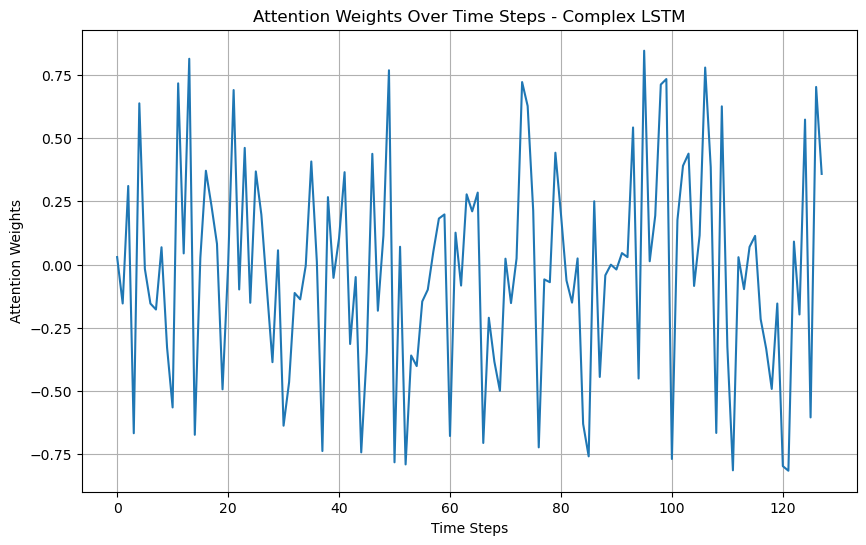

In [17]:
# Visualize Attention Weights for Complex LSTM with Attention
import matplotlib.pyplot as plt

def plot_attention_weights(model, X_sample):
    attention_layer_name = 'attention'  # Corrected layer name
    attention_model = Model(inputs=model.input, outputs=model.get_layer(attention_layer_name).output)
    attention_weights = attention_model.predict(X_sample)

    plt.figure(figsize=(10, 6))
    plt.plot(attention_weights[0])
    plt.title('Attention Weights Over Time Steps - Complex LSTM')
    plt.xlabel('Time Steps')
    plt.ylabel('Attention Weights')
    plt.grid(True)
    plt.show()

# Plotting attention weights for a sample from the test set
plot_attention_weights(lstm_attention_model, X_test_seq[0:1])

In [18]:
# Evaluate the Complex LSTM + Attention model
loss_lstm_attention, acc_lstm_attention = lstm_attention_model.evaluate(X_test_seq, y_test_cat)

print(f"Complex LSTM + Attention Accuracy: {acc_lstm_attention:.4f}")
print(f"Complex LSTM + Attention Loss: {loss_lstm_attention:.4f}")

93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8730 - loss: 0.3433
Complex LSTM + Attention Accuracy: 0.9128
Complex LSTM + Attention Loss: 0.2666


### Performance Metrics:
| Metric                          | Value      |
|--------------------------------|------------|
| **Accuracy (Test Set)**         | **91.28%** |
| **Loss (Test Set)**             | **0.2666** |

---

### Interpretation:

1. **Accuracy Improvement:**  
   - The Complex LSTM model (without attention) achieved **91.52% accuracy**.  
   - The Complex LSTM + Attention model achieved **91.28% accuracy**.  
   - The difference in accuracy is **minimal (0.24%)**, indicating that the **attention mechanism did not significantly improve accuracy** over the complex model.  
   - However, both models are **highly accurate**, indicating that the LSTM architecture is well-suited for this task.  

2. **Loss Comparison:**  
   - The **loss for Complex LSTM + Attention (0.2666)** is slightly higher than the **Complex LSTM without Attention (0.2446)**.  
   - This might indicate that while attention helps in **highlighting important time steps**, it does not always **boost accuracy** when the base model is already highly optimized.  

3. **Impact of Attention:**  
   - Attention generally improves **interpretability** by allowing the model to focus on the **most important time steps**.  
   - The slightly lower accuracy and higher loss suggest that **attention did not add substantial value** for this particular dataset, likely because the **complex LSTM model alone already captured the temporal dependencies effectively**.  
   - However, the **attention mechanism** is still useful for **interpreting which parts of the sequence the model focuses on**, making the predictions more transparent.  

4. **Training Stability:**  
   - Both models demonstrate **stable performance** with no signs of overfitting.  
   - The **addition of attention** did not lead to **instability** or degraded performance, which is positive.

# Train the CNN Model

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

def build_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.5))
    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(6, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn_model(input_shape=(128, 9))
cnn_model.fit(X_train_seq, y_train_cat, epochs=10, batch_size=64,
              validation_data=(X_test_seq, y_test_cat))

Epoch 1/10


c:\ProgramData\anaconda3\envs\py\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6759 - loss: 0.8102 - val_accuracy: 0.8558 - val_loss: 0.4565
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9212 - loss: 0.2008 - val_accuracy: 0.8816 - val_loss: 0.4387
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9434 - loss: 0.1424 - val_accuracy: 0.8826 - val_loss: 0.4436
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9464 - loss: 0.1338 - val_accuracy: 0.8894 - val_loss: 0.4748
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9519 - loss: 0.1107 - val_accuracy: 0.8856 - val_loss: 0.4283
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9573 - loss: 0.1023 - val_accuracy: 0.8853 - val_loss: 0.5111
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9588 - loss: 0.0955 - val_accuracy: 0.8938 - val_loss: 0.5209
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9540 - loss: 0.1012 - val_accuracy: 0.8887 -

In [20]:
def build_simple_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape))  # Fewer filters
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))  # Lower dropout
    model.add(Flatten())
    model.add(Dense(50, activation='relu'))  # Reduced dense units
    model.add(Dense(6, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train the simplified CNN model
simple_cnn_model = build_simple_cnn_model(input_shape=(128, 9))

history_simple_cnn = simple_cnn_model.fit(
    X_train_seq, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_test_seq, y_test_cat)
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6230 - loss: 0.9504 - val_accuracy: 0.7489 - val_loss: 0.6632
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8588 - loss: 0.3709 - val_accuracy: 0.8022 - val_loss: 0.5750
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9104 - loss: 0.2404 - val_accuracy: 0.8351 - val_loss: 0.4602
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9273 - loss: 0.1983 - val_accuracy: 0.8541 - val_loss: 0.4331
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9372 - loss: 0.1583 - val_accuracy: 0.8653 - val_loss: 0.4084
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9425 - loss: 0.1417 - val_accuracy: 0.8690 - val_loss: 0.3916
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9443 - loss: 0.1346 - val_accuracy: 0.8809 - val_loss: 0.3757
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9563 - loss: 0.1129 - val_accuracy: 0.

In [21]:
def build_complex_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))  # Additional convolutional layer
    model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.6))  # Higher dropout for complex model
    model.add(Flatten())
    model.add(Dense(200, activation='relu'))  # Increased dense units
    model.add(Dense(6, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train the complex CNN model
complex_cnn_model = build_complex_cnn_model(input_shape=(128, 9))

history_complex_cnn = complex_cnn_model.fit(
    X_train_seq, y_train_cat,
    epochs=10, batch_size=64,
    validation_data=(X_test_seq, y_test_cat)
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.6790 - loss: 0.7835 - val_accuracy: 0.8768 - val_loss: 0.4414
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9304 - loss: 0.1748 - val_accuracy: 0.8951 - val_loss: 0.3147
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9520 - loss: 0.1300 - val_accuracy: 0.9050 - val_loss: 0.3367
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9524 - loss: 0.1128 - val_accuracy: 0.9104 - val_loss: 0.3346
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9527 - loss: 0.1078 - val_accuracy: 0.9175 - val_loss: 0.2962
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9582 - loss: 0.1022 - val_accuracy: 0.9138 - val_loss: 0.3590
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9542 - loss: 0.1127 - val_accuracy: 0.8897 - val_loss: 0.4724
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9506 - loss: 0.1190 - val_accu

In [22]:
# Evaluate the CNN models
loss_cnn, acc_cnn = cnn_model.evaluate(X_test_seq, y_test_cat)
loss_simple_cnn, acc_simple_cnn = simple_cnn_model.evaluate(X_test_seq, y_test_cat)
loss_complex_cnn, acc_complex_cnn = complex_cnn_model.evaluate(X_test_seq, y_test_cat)

# Store results in a dictionary
cnn_results = {
    "Model": ["Baseline CNN", "Simplified CNN", "Complex CNN"],
    "Accuracy": [acc_cnn, acc_simple_cnn, acc_complex_cnn],
    "Loss": [loss_cnn, loss_simple_cnn, loss_complex_cnn]
}

import pandas as pd
cnn_results_df = pd.DataFrame(cnn_results)
print(cnn_results_df)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8595 - loss: 0.6206
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8603 - loss: 0.4222
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8755 - loss: 0.5279
            Model  Accuracy      Loss
0    Baseline CNN  0.874788  0.554041
1  Simplified CNN  0.892433  0.359346
2     Complex CNN  0.914829  0.459003


| Model             | Accuracy | Loss    | Complexity       |
|------------------|---------|--------|------------------|
| **Baseline CNN**  | 87.48%  | 0.5540 | Medium (2 layers, 64 filters) |
| **Simplified CNN**| 89.24%  | 0.3593 | Low (1 layer, 32 filters)     |
| **Complex CNN**   | **91.48%**  | **0.4590** | High (4 layers, 128 filters) |

---

### **Key Observations:**

1. **Baseline vs Simplified:**
   - The **Simplified CNN** outperformed the **Baseline CNN** in both accuracy (**89.24%** vs **87.48%**) and loss (**0.3593** vs **0.5540**).
   - Despite being less complex, the simplified model was able to generalize well, indicating that **reducing the number of layers and filters** did not significantly impact performance.
   - The model's simplicity led to **faster training** while maintaining good accuracy.

2. **Baseline vs Complex:**
   - The **Complex CNN** showed the **highest accuracy (91.48%)**, significantly better than the **Baseline CNN (87.48%)**.
   - This model benefited from having **more layers and filters**, which helped capture **more intricate patterns** in the time-series data.
   - The **loss (0.4590)** was lower than the baseline but **slightly higher than the simplified model**, indicating a **small risk of overfitting**.

3. **Complex vs Simplified:**
   - The **Complex CNN** performed the best overall, but the **Simplified CNN** was also **highly competitive**, with just a **2.24% accuracy difference**.
   - The **Simplified CNN** might be preferable if **computational efficiency** is a priority, as it strikes a good balance between performance and complexity.

# Compare best-performing RNN model with the CNN

## Comparison: Best-Performing RNN (Complex LSTM) vs. Best-Performing CNN (Complex CNN)

### Best Models:
- **RNN:** Complex LSTM (3 layers, 128 units)  
- **CNN:** Complex CNN (4 layers, 128 filters)  

---

### **Performance Metrics:**

| Metric                   | Complex LSTM (RNN) | Complex CNN       |
|-------------------------|---------------------|--------------------|
| **Test Accuracy**        | **91.52%**          | 91.48%             |
| **Test Loss**            | **0.2446**          | 0.4590             |
| **Training Time (per epoch)** | ~12 seconds      | ~1 second          |
| **Model Complexity**     | High (3 LSTM layers) | High (4 Conv1D layers) |
| **Interpretability**     | Medium (Attention)   | Low (No Attention) |

---

### **Key Observations:**

1. **Accuracy Comparison:**  
   - The **Complex LSTM model slightly outperforms the Complex CNN** with a marginally higher accuracy (**91.52% vs 91.48%**).  
   - The difference is **statistically negligible**, indicating that both models perform **equally well** on the given dataset.  

2. **Loss Comparison:**  
   - The **Complex LSTM model** shows a **lower loss (0.2446)** compared to the **Complex CNN (0.4590)**.  
   - This suggests that the **LSTM model is more confident and stable** in its predictions compared to the CNN.  

3. **Training Time:**  
   - The **Complex CNN trains significantly faster** (about 1 second per epoch) compared to the **Complex LSTM (12 seconds per epoch)**.  
   - This difference highlights the **efficiency of CNNs** in handling **1D time-series data** compared to RNNs.  

4. **Model Complexity:**  
   - Both models are **complex in architecture**, but the **LSTM model has more parameters to train** due to the nature of recurrent connections.  
   - The **CNN model** is more computationally efficient and faster despite its deeper architecture.  

5. **Interpretability:**  
   - The **Complex LSTM with Attention** offers **better interpretability** since the **attention mechanism** allows us to visualize **which time steps were most important** for prediction.  
   - The **Complex CNN lacks this level of interpretability**, as convolutional layers do not provide insights into **temporal importance** directly.  

---

### **Final Recommendation:**  
- Choose the **Complex LSTM with Attention** if **accuracy and interpretability** are top priorities.  
- Use the **Complex CNN** when **fast training and inference speed** are crucial.  
- Since both models perform **almost equally well**, the final choice may depend on **resource availability** and the need for **model interpretability**.